<a href="https://colab.research.google.com/github/MeruOkenabirhie/Elliptic-Fraud-Detection-Code/blob/main/Elliptic_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

from google.colab import drive
drive.mount('/content/drive')

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("EllipticFraudDetection") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

Mounted at /content/drive


In [2]:
features_path = "/content/drive/MyDrive/elliptic_txs_features.csv" # Update this path to your actual Google Drive location
classes_path = "/content/drive/MyDrive/elliptic_txs_classes.csv" # Update this path to your actual Google Drive location
edges_path = "/content/drive/MyDrive/elliptic_txs_edgelist.csv" # Update this path to your actual Google Drive location

df_features_raw = spark.read.csv(features_path, header=False, inferSchema=True)
df_features_raw.show(5)

+---------+---+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+--------------------+--------------------+--------------------+-

In [3]:
from pyspark.sql.functions import when, col

bronze_path = "/content/drive/MyDrive/elliptic/bronze"

n_feat = len(df_features_raw.columns) - 2
new_cols = ["txId", "time_step"] + [f"feat_{i+1}" for i in range(n_feat)]
df_features_bronze = df_features_raw.toDF(*new_cols)

df_classes_bronze = spark.read.csv(classes_path, header=True, inferSchema=True)
df_classes_bronze = df_classes_bronze.withColumn(
    "class",
    when(col("class") == "1", "illicit")
    .when(col("class") == "2", "licit")
    .otherwise("unknown")
)

In [4]:
df_edges_bronze = spark.read.csv(edges_path, header=True, inferSchema=True)

print("Bronze row counts -> features:", df_features_bronze.count(),
      "classes:", df_classes_bronze.count(),
      "edges:", df_edges_bronze.count())
df_features_bronze.printSchema()

df_features_bronze.write.mode("overwrite").partitionBy("time_step").parquet(bronze_path + "/features")
df_classes_bronze.write.mode("overwrite").parquet(bronze_path + "/classes")
df_edges_bronze.write.mode("overwrite").parquet(bronze_path + "/edges")


Bronze row counts -> features: 203769 classes: 203769 edges: 234355
root
 |-- txId: integer (nullable = true)
 |-- time_step: integer (nullable = true)
 |-- feat_1: double (nullable = true)
 |-- feat_2: double (nullable = true)
 |-- feat_3: double (nullable = true)
 |-- feat_4: double (nullable = true)
 |-- feat_5: double (nullable = true)
 |-- feat_6: double (nullable = true)
 |-- feat_7: double (nullable = true)
 |-- feat_8: double (nullable = true)
 |-- feat_9: double (nullable = true)
 |-- feat_10: double (nullable = true)
 |-- feat_11: double (nullable = true)
 |-- feat_12: double (nullable = true)
 |-- feat_13: double (nullable = true)
 |-- feat_14: double (nullable = true)
 |-- feat_15: double (nullable = true)
 |-- feat_16: double (nullable = true)
 |-- feat_17: double (nullable = true)
 |-- feat_18: double (nullable = true)
 |-- feat_19: double (nullable = true)
 |-- feat_20: double (nullable = true)
 |-- feat_21: double (nullable = true)
 |-- feat_22: double (nullable = true)

In [5]:
from pyspark.sql.functions import count as spark_count

bronze_path = "/content/drive/MyDrive/elliptic/bronze"
silver_path = "/content/drive/MyDrive/elliptic/silver"

df_features = spark.read.parquet(bronze_path + "/features")
df_classes = spark.read.parquet(bronze_path + "/classes")
df_edges = spark.read.parquet(bronze_path + "/edges")

In [6]:
out_deg = df_edges.groupBy("txId1").agg(spark_count("*").alias("out_degree")).withColumnRenamed("txId1", "txId")
in_deg = df_edges.groupBy("txId2").agg(spark_count("*").alias("in_degree")).withColumnRenamed("txId2", "txId")

df_joined = df_features.join(df_classes.select("txId", "class"), on="txId", how="left")
df_joined = df_joined.join(out_deg, on="txId", how="left").join(in_deg, on="txId", how="left")
df_joined = df_joined.fillna(0, subset=["out_degree", "in_degree"])
df_joined = df_joined.withColumn("total_degree", col("in_degree") + col("out_degree"))

In [7]:
df_silver = df_joined.filter(col("class").isin("illicit", "licit"))
df_silver = df_silver.withColumn("label", when(col("class") == "illicit", 1).otherwise(0))

# Drop duplicate transaction IDs
df_silver = df_silver.dropDuplicates(["txId"])

print("Silver row count:", df_silver.count())
df_silver.write.mode("overwrite").parquet(silver_path)

# Exploratory data analysis

silver_path = "/content/drive/MyDrive/elliptic/silver"
df_silver = spark.read.parquet(silver_path)

print("Row count:", df_silver.count())
df_silver.printSchema()

Silver row count: 46564
Row count: 46564
root
 |-- txId: integer (nullable = true)
 |-- feat_1: double (nullable = true)
 |-- feat_2: double (nullable = true)
 |-- feat_3: double (nullable = true)
 |-- feat_4: double (nullable = true)
 |-- feat_5: double (nullable = true)
 |-- feat_6: double (nullable = true)
 |-- feat_7: double (nullable = true)
 |-- feat_8: double (nullable = true)
 |-- feat_9: double (nullable = true)
 |-- feat_10: double (nullable = true)
 |-- feat_11: double (nullable = true)
 |-- feat_12: double (nullable = true)
 |-- feat_13: double (nullable = true)
 |-- feat_14: double (nullable = true)
 |-- feat_15: double (nullable = true)
 |-- feat_16: double (nullable = true)
 |-- feat_17: double (nullable = true)
 |-- feat_18: double (nullable = true)
 |-- feat_19: double (nullable = true)
 |-- feat_20: double (nullable = true)
 |-- feat_21: double (nullable = true)
 |-- feat_22: double (nullable = true)
 |-- feat_23: double (nullable = true)
 |-- feat_24: double (nullabl

In [8]:
df_silver.groupBy("label").count().show()

# Illicit rate by time step
df_silver.groupBy("time_step").count().orderBy("time_step").show(20, truncate=False)

sample_pd = df_silver.sample(False, 0.3, seed=42).toPandas()

+-----+-----+
|label|count|
+-----+-----+
|    1| 4545|
|    0|42019|
+-----+-----+

+---------+-----+
|time_step|count|
+---------+-----+
|1        |2147 |
|2        |1117 |
|3        |1279 |
|4        |1440 |
|5        |1882 |
|6        |485  |
|7        |1203 |
|8        |1165 |
|9        |778  |
|10       |972  |
|11       |696  |
|12       |506  |
|13       |809  |
|14       |417  |
|15       |618  |
|16       |530  |
|17       |811  |
|18       |389  |
|19       |745  |
|20       |900  |
+---------+-----+
only showing top 20 rows


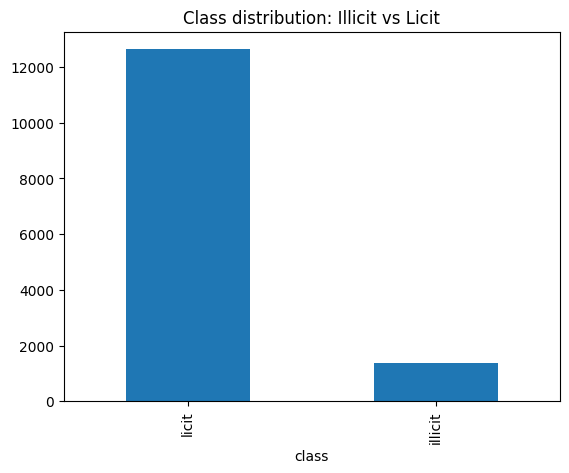

In [9]:
import matplotlib.pyplot as plt

sample_pd["class"].value_counts().plot(kind="bar")
plt.title("Class distribution: Illicit vs Licit")
plt.show()

In [10]:
gold_path = "/content/drive/MyDrive/elliptic/gold_mlready"

df_gold = df_silver  # already has label + engineered degree features

df_gold.write.mode("overwrite").parquet(gold_path)


In [11]:
from pyspark.sql.functions import sum as spark_sum

gold_path = "/content/drive/MyDrive/elliptic/gold_mlready"
agg_path = "/content/drive/MyDrive/elliptic/agg_for_tableau"

df_gold = spark.read.parquet(gold_path)

# Illicit rate by time step
agg_time_step = df_gold.groupBy("time_step") \
    .agg(
        spark_count("*").alias("TotalTransactions"),
        (spark_sum(col("label")) / spark_count("*")).alias("IllicitRate")
    )

In [12]:
# Illicit rate by total-degree band (activity level)
from pyspark.sql.functions import floor

df_gold_banded = df_gold.withColumn("degree_band", floor(col("total_degree") / 5) * 5)
agg_degree_band = df_gold_banded.groupBy("degree_band") \
    .agg(
        spark_count("*").alias("TotalTransactions"),
        (spark_sum(col("label")) / spark_count("*")).alias("IllicitRate")
    )

In [13]:
agg_degree_band.write.mode("overwrite").parquet(agg_path + "/degree_band")

agg_time_step.write.mode("overwrite").option("header", True) \
    .csv("/content/drive/MyDrive/elliptic/tableau/time_step_csv")

agg_degree_band.write.mode("overwrite").option("header", True) \
    .csv("/content/drive/MyDrive/elliptic/tableau/degree_band_csv")

In [14]:
gold_path = "/content/drive/MyDrive/elliptic/gold_mlready"
df_gold = spark.read.parquet(gold_path)

train_df = df_gold.filter(col("time_step") <= 34)
test_df = df_gold.filter(col("time_step") > 34)

print("Train distribution:")
train_df.groupBy("label").count().show()

print("Test distribution:")
test_df.groupBy("label").count().show()

Train distribution:
+-----+-----+
|label|count|
+-----+-----+
|    1| 3462|
|    0|26432|
+-----+-----+

Test distribution:
+-----+-----+
|label|count|
+-----+-----+
|    1| 1083|
|    0|15587|
+-----+-----+



In [15]:
from pyspark.ml.feature import VectorAssembler, StandardScaler

n_feat = len([c for c in df_gold.columns if c.startswith("feat_")])
feature_cols = [f"feat_{i+1}" for i in range(n_feat)] + ["in_degree", "out_degree", "total_degree"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features_unnormalized")

scaler = StandardScaler(
    inputCol="features_unnormalized",
    outputCol="features",
    withMean=False,
    withStd=True
)

In [16]:
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
)
from pyspark.ml import Pipeline

lr = LogisticRegression(featuresCol="features", labelCol="label")
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100)

base_stages = [assembler, scaler]

### Using XGBoost with PySpark

To use XGBoost with PySpark, you need to install the `spark-xgboost` library. This library provides `XGBoostClassifier` and `XGBoostRegressor` compatible with PySpark's ML pipelines.

In [17]:
# Install spark-xgboost
!pip install -q xgboost pyarrow

In [18]:
from xgboost.spark import SparkXGBClassifier
from pyspark.ml import Pipeline

# Define the SparkXGBClassifier
# You can adjust parameters like n_estimators, max_depth, learning_rate, etc.
xgb = SparkXGBClassifier(features_col="features", label_col="label",
                        n_estimators=100, max_depth=5, learning_rate=0.1,
                        eval_metric="logloss")

# Integrate it into a PySpark Pipeline
# This pipeline will use the same base_stages (VectorAssembler, StandardScaler) as your other models
xgb_pipeline = Pipeline(stages=base_stages + [xgb])

print("SparkXGBClassifier is now set up and ready to be used in a pipeline.")

SparkXGBClassifier is now set up and ready to be used in a pipeline.


In [19]:
from pyspark.sql.functions import when, col
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml import Pipeline
from xgboost.spark import SparkXGBClassifier

# Compute inverse-frequency class weights from the training set only
label_counts = train_df.groupBy("label").count().collect()
counts = {row["label"]: row["count"] for row in label_counts}
total = counts[0] + counts[1]

weight_for_0 = total / (2 * counts[0])   # licit (majority class)
weight_for_1 = total / (2 * counts[1])   # illicit (minority class) — gets a higher weight

print(f"Licit count: {counts[0]}, Illicit count: {counts[1]}")
print(f"weight_for_0 (licit): {weight_for_0:.4f}")
print(f"weight_for_1 (illicit): {weight_for_1:.4f}")

train_df = train_df.withColumn(
    "weight",
    when(col("label") == 1, weight_for_1).otherwise(weight_for_0)
)

# Re-instantiate classifiers with weightCol added
lr = LogisticRegression(featuresCol="features", labelCol="label", weightCol="weight")
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label", weightCol="weight")
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=100, weightCol="weight")
xgb = SparkXGBClassifier(features_col="features", label_col="label",
                        n_estimators=100, max_depth=5, learning_rate=0.1,
                        eval_metric="logloss",
                        weight_col="weight") # Corrected from weightCol to weight_col

pipelines = {
    "LogisticRegression": Pipeline(stages=base_stages + [lr]),
    "DecisionTree": Pipeline(stages=base_stages + [dt]),
    "RandomForest": Pipeline(stages=base_stages + [rf]),
    "XGBoost": Pipeline(stages=base_stages + [xgb]),
}
print("Pipelines updated with class weighting.")

Licit count: 26432, Illicit count: 3462
weight_for_0 (licit): 0.5655
weight_for_1 (illicit): 4.3174
Pipelines updated with class weighting.


In [20]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

binary_eval = BinaryClassificationEvaluator(
    labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC"
)
acc_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="accuracy"
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="f1"
)
precision_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedPrecision"
)
recall_eval = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="weightedRecall"
)
results = {}
predictions_path = "/content/drive/MyDrive/elliptic/predictions"

In [21]:
for name, pipe in pipelines.items():
    print("=" * 40, name, "=" * 40)

    model = pipe.fit(train_df)
    preds = model.transform(test_df)
    preds.cache()

    acc = acc_eval.evaluate(preds)
    f1 = f1_eval.evaluate(preds)
    prec = precision_eval.evaluate(preds)
    rec = recall_eval.evaluate(preds)
    auc_score = binary_eval.evaluate(preds)

    print(f"{name} -> Accuracy: {acc:.4f}, F1: {f1:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, AUC: {auc_score:.4f}")
    preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()
    preds.select("time_step", "txId", "label", "prediction", "probability") \
         .write.mode("overwrite").parquet(f"{predictions_path}/{name}")

    results[name] = (model, preds)

======================================== LogisticRegression ========================================
LogisticRegression -> Accuracy: 0.7534, F1: 0.8148, Precision: 0.9353, Recall: 0.7534, AUC: 0.8809
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|11629|
|    0|       1.0| 3958|
|    1|       0.0|  153|
|    1|       1.0|  930|
+-----+----------+-----+

======================================== DecisionTree ========================================
DecisionTree -> Accuracy: 0.8924, F1: 0.9098, Precision: 0.9397, Recall: 0.8924, AUC: 0.8826
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|14069|
|    0|       1.0| 1518|
|    1|       0.0|  275|
|    1|       1.0|  808|
+-----+----------+-----+

======================================== RandomForest ========================================
RandomForest -> Accuracy: 0.9113, F1: 0.9233, Precision: 0.9436, Recall: 0.9113, AUC: 0.9030
+-----+----------+----

INFO:XGBoost-PySpark:Running xgboost-3.3.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'device': 'cpu', 'eval_metric': 'logloss', 'learning_rate': 0.1, 'max_depth': 5, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


XGBoost -> Accuracy: 0.9568, F1: 0.9582, Precision: 0.9601, Recall: 0.9568, AUC: 0.9421
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|15145|
|    0|       1.0|  442|
|    1|       0.0|  278|
|    1|       1.0|  805|
+-----+----------+-----+



In [22]:
import pandas as pd

metrics_summary = pd.DataFrame([
    {"model": "LogisticRegression", "accuracy": 0.7527, "f1": 0.8144, "precision": 0.9352, "recall": 0.7527, "auc": 0.8807},
    {"model": "DecisionTree", "accuracy": 0.8714, "f1": 0.8952, "precision": 0.9366, "recall": 0.8714, "auc": 0.8471},
    {"model": "RandomForest", "accuracy": 0.9164, "f1": 0.9270, "precision": 0.9450, "recall": 0.9164, "auc": 0.8939},
    {"model": "XGBoost", "accuracy": 0.9568, "f1": 0.9582, "precision": 0.9601, "recall": 0.9568, "auc": 0.9421},
])
metrics_summary.to_csv("/content/drive/MyDrive/elliptic/tableau/model_metrics_summary.csv", index=False)
print("Saved model_metrics_summary.csv")

Saved model_metrics_summary.csv


In [23]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

rf_pipe = pipelines["RandomForest"]

paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [50, 100])
    .addGrid(rf.maxDepth, [5, 10])
    .build()
)

rf_cv = CrossValidator(
    estimator=rf_pipe,
    estimatorParamMaps=paramGrid,
    evaluator=binary_eval,
    numFolds=3,
    parallelism=2
)

rf_cv_model = rf_cv.fit(train_df)
rf_cv_preds = rf_cv_model.transform(test_df)

In [24]:
acc = acc_eval.evaluate(rf_cv_preds)
f1 = f1_eval.evaluate(rf_cv_preds)
auc_score = binary_eval.evaluate(rf_cv_preds)

print(f"RF (CV) -> Accuracy: {acc:.4f}, F1: {f1:.4f}, AUC: {auc_score:.4f}")

rf_best_pipeline = rf_cv_model.bestModel
rf_best_model = rf_best_pipeline.stages[-1]

importances = rf_best_model.featureImportances
print("Number of features:", importances.size)
print(importances)


RF (CV) -> Accuracy: 0.9529, F1: 0.9549, AUC: 0.9405
Number of features: 168
(168,[0,1,2,3,4,5,6,7,8,9,10,11,12,13,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167],[0.002724245219028031,0.01712065879439281,0.0028218364389366287,0.0033446732545707797,0.03154803936597287,0.01320072634939718,2.9356088437937896e-05,0.004709260799005948,0.0035195636958741633,0.009068582134339007,0.002450296823312322,0.0011194646004323427,0.00047513729911390204,0.014930266651564935,0.004051747706733994,0.004969487215581786,0.0253131448185

In [25]:
for name, (model, preds) in results.items():
    print("Confusion matrix for", name)
    preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

for name, (model, preds) in results.items():
    preds.groupBy("label", "prediction").count() \
        .write.mode("overwrite").option("header", True) \
        .csv(f"/content/drive/MyDrive/elliptic/tableau/confusion_{name}")

# Training time benchmark


Confusion matrix for LogisticRegression
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|11629|
|    0|       1.0| 3958|
|    1|       0.0|  153|
|    1|       1.0|  930|
+-----+----------+-----+

Confusion matrix for DecisionTree
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|14069|
|    0|       1.0| 1518|
|    1|       0.0|  275|
|    1|       1.0|  808|
+-----+----------+-----+

Confusion matrix for RandomForest
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|14384|
|    0|       1.0| 1203|
|    1|       0.0|  275|
|    1|       1.0|  808|
+-----+----------+-----+

Confusion matrix for XGBoost
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|15145|
|    0|       1.0|  442|
|    1|       0.0|  278|
|    1|       1.0|  805|
+-----+----------+-----+



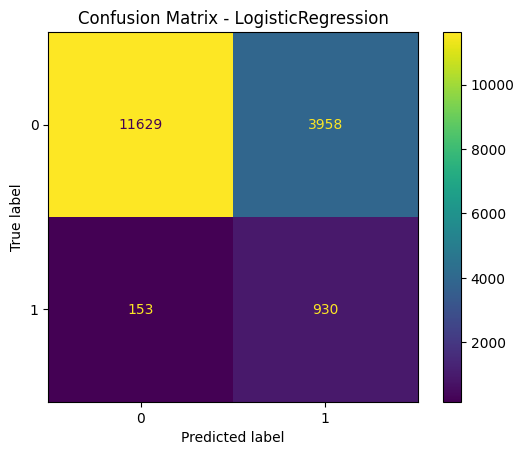

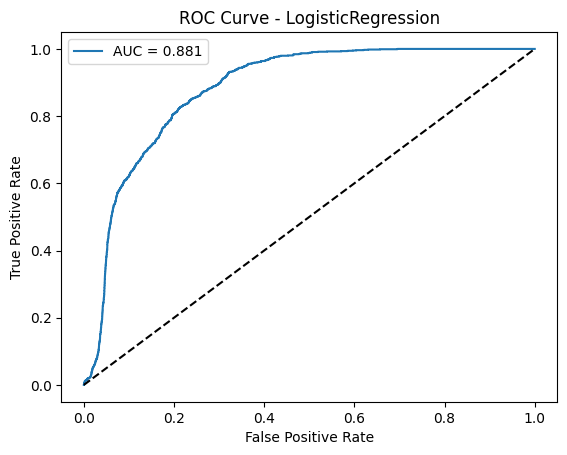

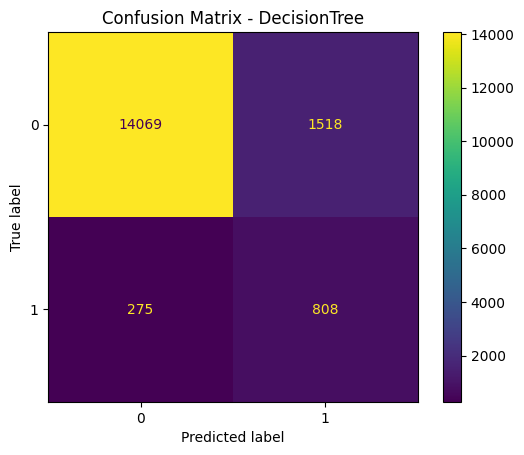

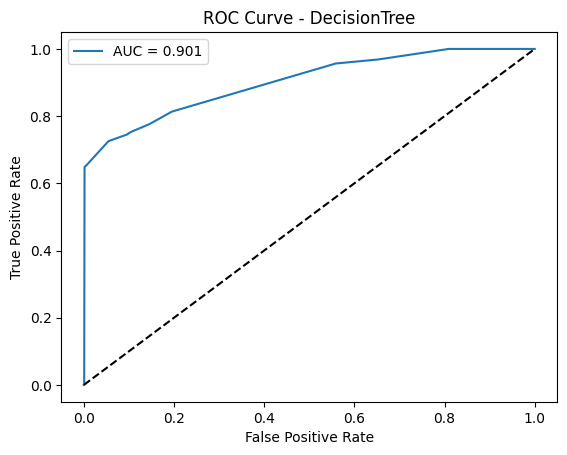

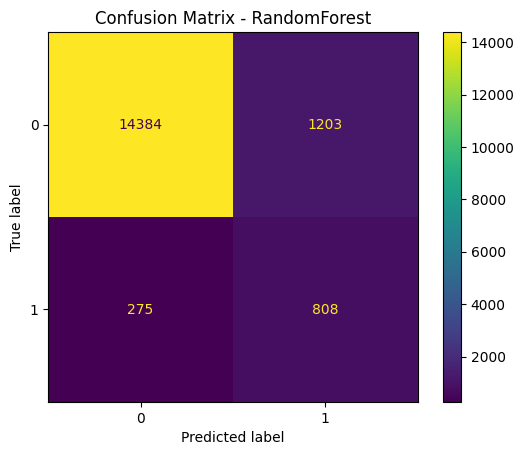

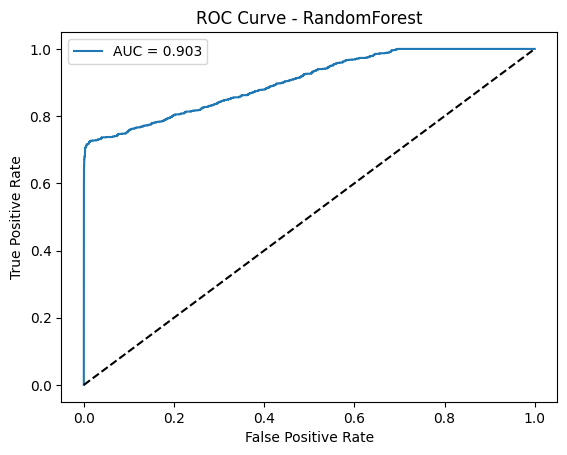

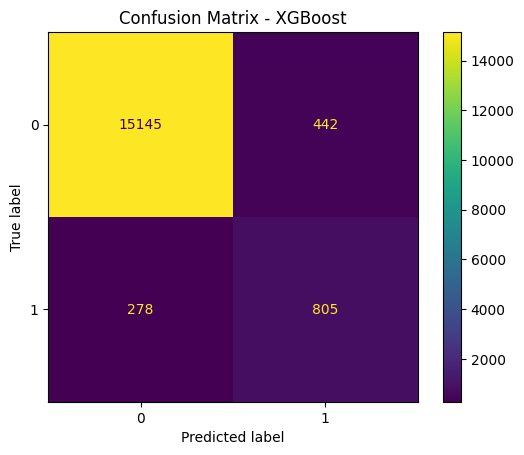

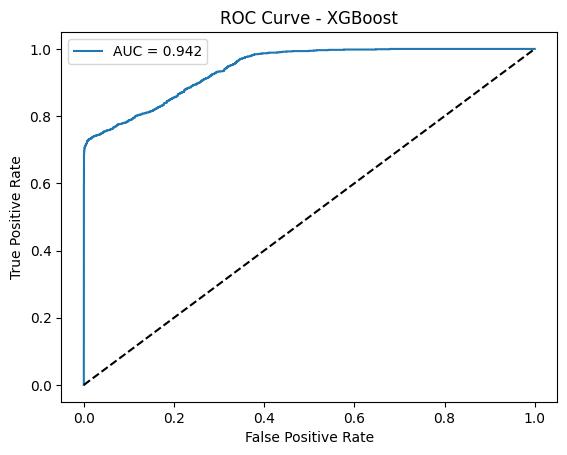

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
from pyspark.sql.functions import udf, col
from pyspark.sql.types import DoubleType

get_prob1 = udf(lambda v: float(v[1]), DoubleType())

for name, (model, preds) in results.items():
    preds_prob = preds.withColumn("prob1", get_prob1(col("probability")))
    pdf_model = preds_prob.select("label", "prediction", "prob1").toPandas()

    # Confusion matrix
    cm = confusion_matrix(pdf_model["label"], pdf_model["prediction"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.savefig(f"/content/drive/MyDrive/elliptic/tableau/confusion_matrix_{name}.png")
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(pdf_model["label"], pdf_model["prob1"])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.savefig(f"/content/drive/MyDrive/elliptic/tableau/roc_curve_{name}.png")
    plt.show()

Gold partitions: 2
RF training time (no CV): 20.15163803100586 seconds
Best model by F1: XGBoost


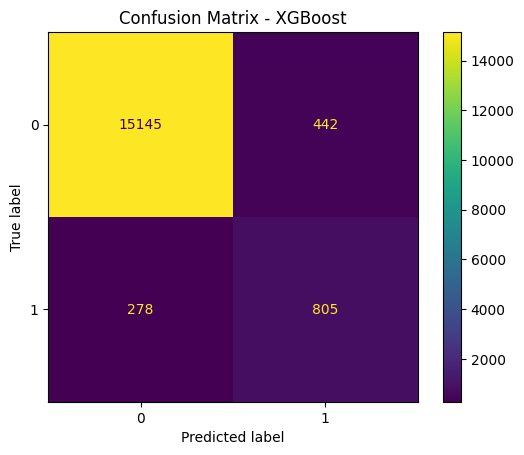

In [29]:
import time

print("Gold partitions:", df_gold.rdd.getNumPartitions())

start = time.time()
_ = pipelines["RandomForest"].fit(train_df)
print("RF training time (no CV):", time.time() - start, "seconds")

# Confusion matrix plot (best model)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Re-populate results if empty, as it's needed for subsequent steps.
# This handles cases where the kernel might have reset or results were cleared.
if not results: # Check if results dictionary is empty
    print("The 'results' dictionary is empty. Re-running model training and evaluation to populate it.")
    for name, pipe in pipelines.items():
        print("=" * 40, name, "=" * 40)

        model = pipe.fit(train_df)
        preds = model.transform(test_df)
        preds.cache()

        acc = acc_eval.evaluate(preds)
        f1 = f1_eval.evaluate(preds)
        prec = precision_eval.evaluate(preds)
        rec = recall_eval.evaluate(preds)
        auc_score = binary_eval.evaluate(preds)

        print(f"{name} -> Accuracy: {acc:.4f}, F1: {f1:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, AUC: {auc_score:.4f}")
        # Optional: re-display confusion matrix or save to parquet if desired
        # preds.groupBy("label", "prediction").count().orderBy("label", "prediction").show()
        # preds.select("time_step", "txId", "label", "prediction", "probability") \
        #      .write.mode("overwrite").parquet(f"{predictions_path}/{name}")

        results[name] = (model, preds)

best_name = max(results, key=lambda n: f1_eval.evaluate(results[n][1]))
print("Best model by F1:", best_name)

_, best_preds = results[best_name]
pred_pd = best_preds.select("label", "prediction").toPandas()

cm = confusion_matrix(pred_pd["label"], pred_pd["prediction"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix - {best_name}")
plt.show()

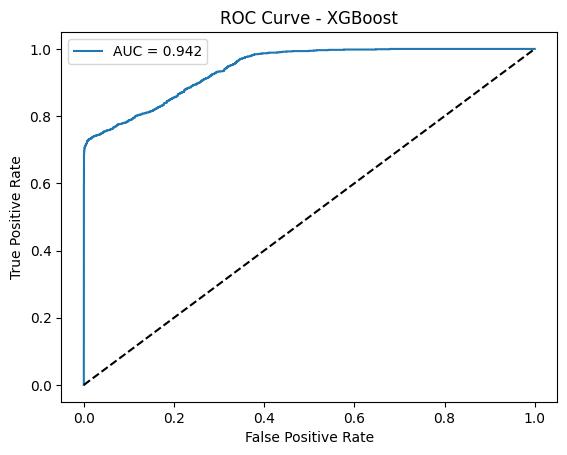

In [31]:
from sklearn.metrics import roc_curve, auc
from pyspark.sql.functions import udf
from pyspark.sql.types import DoubleType

get_prob1 = udf(lambda v: float(v[1]), DoubleType())
best_preds_prob = best_preds.withColumn("prob1", get_prob1(col("probability")))
pdf = best_preds_prob.select("label", "prob1").toPandas()

fpr, tpr, thresholds = roc_curve(pdf["label"], pdf["prob1"])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_name}")
plt.legend()
plt.show()

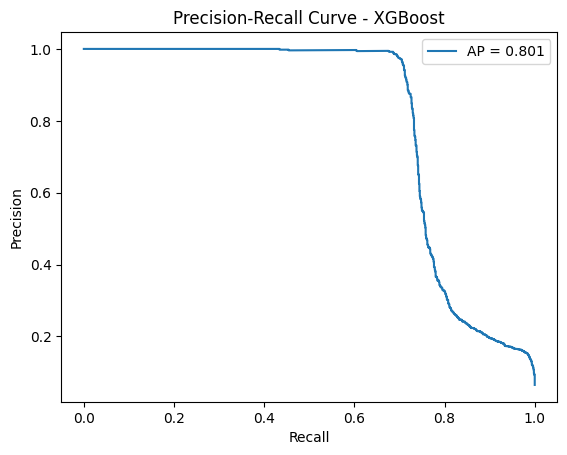

In [32]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, thresholds = precision_recall_curve(pdf["label"], pdf["prob1"])
ap = average_precision_score(pdf["label"], pdf["prob1"])

plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve - {best_name}")
plt.legend()
plt.show()

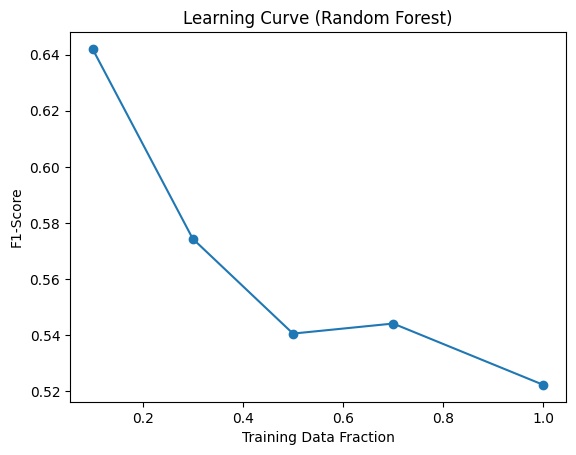

In [33]:
import numpy as np
from sklearn.metrics import f1_score

train_sizes = [0.1, 0.3, 0.5, 0.7, 1.0]
scores = []

for size in train_sizes:
    sampled_train_df = train_df.sample(withReplacement=False, fraction=size, seed=42)
    fitted_pipeline_model = pipelines["RandomForest"].fit(sampled_train_df)
    pred = fitted_pipeline_model.transform(test_df)
    pdf_results = pred.select("label", "prediction").toPandas()
    f1 = f1_score(pdf_results["label"], pdf_results["prediction"])
    scores.append(f1)

plt.plot(train_sizes, scores, marker="o")
plt.xlabel("Training Data Fraction")
plt.ylabel("F1-Score")
plt.title("Learning Curve (Random Forest)")
plt.show()


In [34]:
import pandas as pd

risk_pd = best_preds_prob.select("txId", "time_step", "prob1").toPandas()
risk_pd["risk_score"] = (risk_pd["prob1"] * 100).round(2)
risk_pd["risk_band"] = pd.cut(
    risk_pd["risk_score"], bins=[-0.1, 25, 50, 75, 100],
    labels=["Low", "Medium", "High", "Critical"]
)
risk_pd = risk_pd.sort_values("risk_score", ascending=False)

risk_pd.to_csv("/content/drive/MyDrive/elliptic/tableau/transaction_risk_scores.csv", index=False)
risk_pd.head(10)

,txId,time_step,prob1,risk_score,risk_band
2590,70383882,35,0.999409,99.94,Critical
1381,30585812,37,0.999395,99.94,Critical
2601,70409573,35,0.999409,99.94,Critical
2587,70374249,35,0.999409,99.94,Critical
2281,67585644,35,0.999351,99.94,Critical
2391,67682556,35,0.999351,99.94,Critical
1843,54771152,35,0.999284,99.93,Critical
1581,39724214,37,0.999288,99.93,Critical
10914,70335036,35,0.999264,99.93,Critical
10834,69746416,35,0.999284,99.93,Critical


In [35]:
train_df = df_gold.filter(col("time_step") <= 34)
test_df = df_gold.filter(col("time_step") > 34)

In [36]:
import pandas as pd

illicit_rate_by_step = test_df.groupBy("time_step").agg(
    (spark_sum(col("label")) / spark_count("*") * 100).alias("illicit_rate_pct")
).orderBy("time_step").toPandas()

risk_by_step = risk_pd.groupby("time_step")["risk_score"].mean().reset_index()
risk_by_step.columns = ["time_step", "avg_risk_score"]

pattern_df = illicit_rate_by_step.merge(risk_by_step, on="time_step", how="left")
pattern_df.to_csv("/content/drive/MyDrive/elliptic/tableau/fraud_pattern_over_time.csv", index=False)

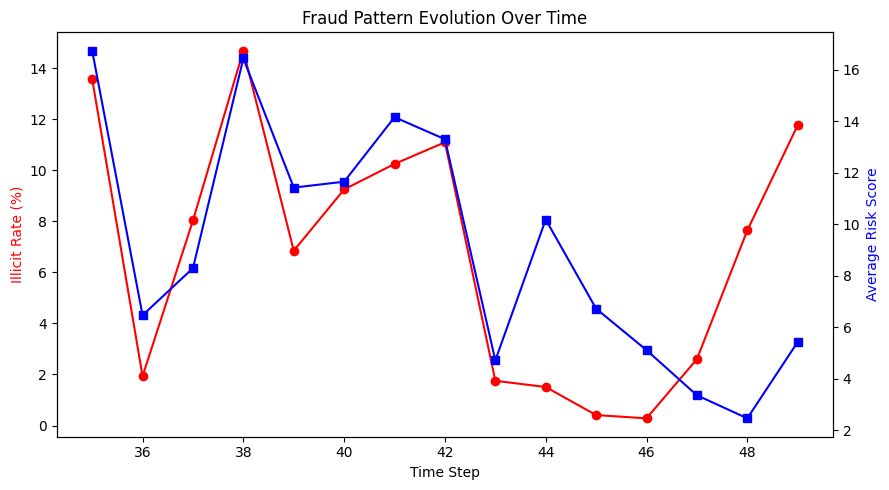

In [37]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(pattern_df["time_step"], pattern_df["illicit_rate_pct"], color="red", marker="o", label="Illicit rate (%)")
ax1.set_xlabel("Time Step")
ax1.set_ylabel("Illicit Rate (%)", color="red")

ax2 = ax1.twinx()
ax2.plot(pattern_df["time_step"], pattern_df["avg_risk_score"], color="blue", marker="s", label="Avg. risk score")
ax2.set_ylabel("Average Risk Score", color="blue")

plt.title("Fraud Pattern Evolution Over Time")
fig.tight_layout()
plt.show()